<center><img src="mmu.png"/></center>

<h2><center>TDW 3311 Data Wrangling and Visualisation</center></h2>
<h2><center>Lab 08 - Static Visualisation</center></h2>

This lab introduces different types of static visualisation. You will create a variety of plots and become proficient in selecting the right kind of visualisation to represent global patterns in data.

Generate two simple plots using Seaborn and Pandas — histograms and bar plots:

-  Histograms: Histograms are useful for understanding the statistical distribution of a numerical feature in a given dataset. They can be generated using the hist() function in Pandas and histplot() in Seaborn.
-  Bar plots: Bar plots are useful for gaining insight into the values taken by a categorical feature in a given dataset. They can be generated using the plot(kind='bar') function in Pandas and the catplot(kind='count'), and barplot() functions in Seaborn.

## Task 1: Plotting and analysing a histogram

1. Import the necessary modules.

In [96]:
import seaborn as sns # data visualization library based on matplotlib
import pandas as pd # library for data manipulation and analysis
import numpy as np
import matplotlib.pyplot as plt

2. Import the diamonds dataset from Seaborn.

In [58]:
diamonds_df = sns.load_dataset('diamonds') # dataset from Seaborn

diamonds_df.head() # show the top 5 records in the dataset

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


3. Plot a histogram using the diamonds dataset. The x-axis = carat.

array([[<AxesSubplot:title={'center':'carat'}>]], dtype=object)

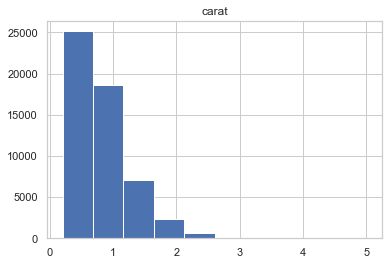

In [59]:
diamonds_df.hist(column = 'carat')

The y-axis in this plot denotes the number of diamonds in the dataset with the <b>carat</b> specification on the x-axis. The <b>hist</b> function has a parameter called bins, which literally refers to the number of equally sized bins into which the data points are divided. The default number of bins is 10.

4. Change the bins parameter to 50 to see a more fine-grained distribution as we increase the number of bins. It is helpful to test with multiple bin sizes to know the exact distribution of the feature.

array([[<AxesSubplot:title={'center':'carat'}>]], dtype=object)

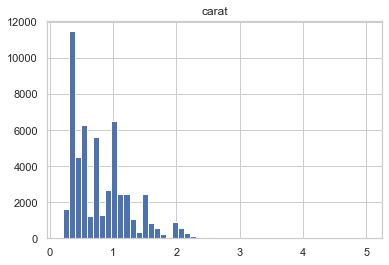

In [60]:
diamonds_df.hist(column = 'carat', bins = 50)

5. Now, create the histogram using Seaborn.

<AxesSubplot:xlabel='carat', ylabel='Count'>

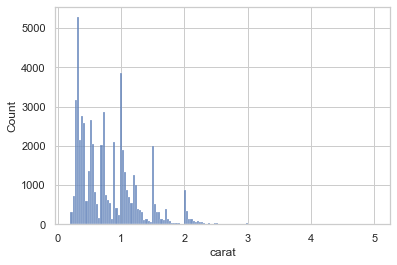

In [61]:
sns.histplot(diamonds_df.carat)

One noticeable difference between the hist function in Pandas and Seaborn's histplot:
The default bin size of the hist function is 10, whereas Seaborn creates an appropriate bin size based on the the statistical distribution of the dataset.

6. Change the bin size to 100.

<AxesSubplot:xlabel='carat', ylabel='Count'>

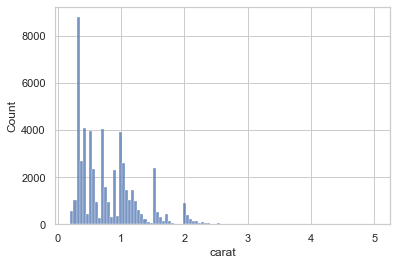

In [62]:
sns.histplot(diamonds_df.carat, bins=100)

The histogram with 100 bins shows a better visualization of the distribution of the variable—we can see that there are several peaks at specific carat values. Another observation is that most carat values are concentrated toward lower values and the tail is on the right—in other words, it is right-skewed.

A <b>log transformation</b> helps in identifying more trends. For instance, in the following graph, the x-axis shows log-transformed values of the price variable, and we can see that there are two peaks indicating two kinds of diamonds — one with a high price and another with a low price.

7. Use a log transformation on the histogram.

<AxesSubplot:xlabel='price', ylabel='Count'>

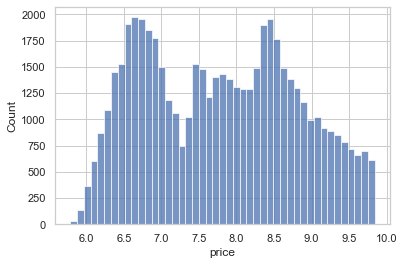

In [63]:
import numpy as np

sns.histplot(np.log(diamonds_df.price))

Looking at the histogram, even a naive viewer can immediately get a picture of the distribution of the feature. Specifically, three observations are important in a histogram:

-  Which feature values are more frequent in the dataset (in this case, there is a peak at around 6.6 and another peak at around 8.5)
-  How many peaks exist in the data (the peaks need to be further inspected for possible causes in the context of the data)
-  Whether there are any outliers in the data

## Task 2: Plotting and analysing a bar plot

1. Print the unique values of the cut and clarity columns.

-  unique() returns an array. There are 5 unique cut qualities and 8 unique values in clarity. The number of unique values can be obtained using nunique() in Pandas.

In [64]:
diamonds_df.cut.unique()

['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']

In [65]:
diamonds_df.clarity.unique()

['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']

2. To obtain the counts of diamonds of each cut quality, we first create a table using the Pandas crosstab() function.

In [66]:
cut_count_table = pd.crosstab(index = diamonds_df['cut'], columns = 'count')
cut_count_table

col_0,count
cut,
Ideal,21551
Premium,13791
Very Good,12082
Good,4906
Fair,1610


3. Pass these counts to the function plot(kind='bar').

<AxesSubplot:xlabel='cut'>

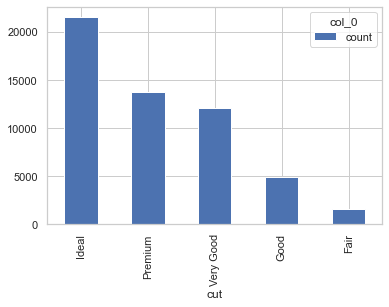

In [67]:
cut_count_table.plot(kind='bar')

4. Now, create a bar plot using Seaborn.

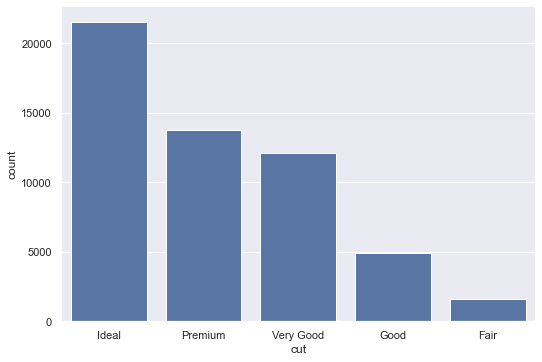

In [68]:
sns.set()
sns.catplot(data=diamonds_df, x="cut", aspect=1.5, kind="count", color="b")

5. Sort the bars in ascending order.

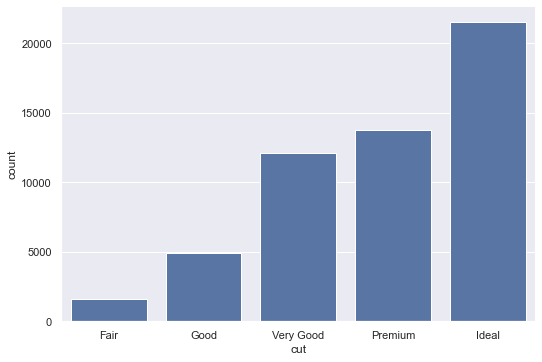

In [69]:
sns.set()
sns.catplot(data=diamonds_df, x="cut", aspect=1.5, kind="count", color="b", order=diamonds_df['cut'].value_counts(ascending=True).index)

6. Obtain the mean price of each cut quality using Seaborn.

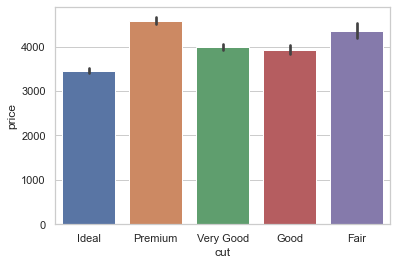

In [70]:
from numpy import median, mean

sns.set(style="whitegrid")
ax = sns.barplot(x="cut", y="price", data=diamonds_df, estimator=mean)

Here, the black lines (error bars) on the bars indicate the uncertainty (or spread of values) around the mean estimate. By default, this value is set to 95% confidence. How do we change it? We use ci = 95, for instance, you can try to
set it to 68%. We can also plot the standard deviation in the prices using ci=sd.

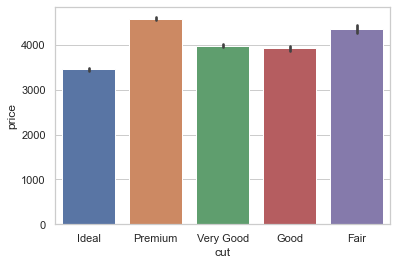

In [83]:
import seaborn as sns # data visualization library based on matplotlib
import pandas as pd # library for data manipulation and analysis

ax=sns.barplot(x="cut", y="price", data=diamonds_df, estimator=mean, ci=68)


7. Add values to the bars.

In [89]:
!pip install matplotlib

DEPRECATION: pyodbc 4.0.0-unsupported has a non-standard version number. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pyodbc or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


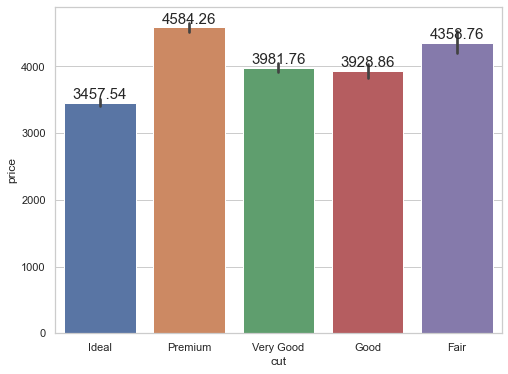

In [97]:
plt.figure(figsize=(8, 6))
splot=sns.barplot(x="cut",y="price",data=diamonds_df)

for bar in splot.patches:
    splot.annotate(format(bar.get_height(), '.2f'), 
                   (bar.get_x() + bar.get_width() / 2, 
                    bar.get_height()), ha='center', va='center',
                   size=15, xytext=(0, 8),
                   textcoords='offset points')
plt.show()


<b>Grouped bar plots</b> (or clustered column chart) can be very useful for visualizing the variation of a particular feature within different groups. Tweaking the plot parameters to generate a bar plot grouped by a specific feature.

8. Use the <i>hue</i> parameter to plot nested groups.

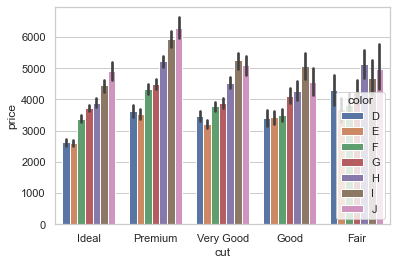

In [40]:
ax = sns.barplot(x="cut", y="price", hue='color', data=diamonds_df)

9. Tweak the plot parameters to adjust the placements of the legends and the axis labels, as well as to change the font size and rotation of the tick labels. Then, add a title to the plot.

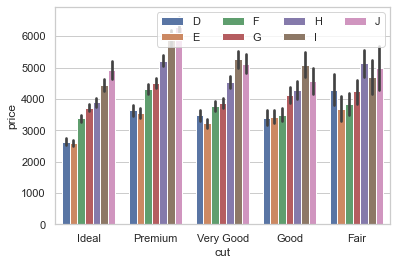

In [41]:
# Modifying legends
ax = sns.barplot(x='cut', y='price', hue='color', data=diamonds_df)
ax.legend(loc='upper right', ncol=4)

Text(0, 0.5, 'Price')

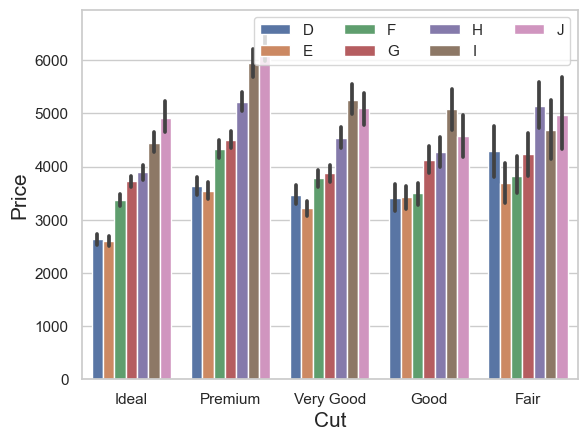

In [19]:
# Modifying x and y-axes tick labels
ax = sns.barplot(x='cut', y='price', hue='color', data=diamonds_df)
ax.legend(loc='upper right', ncol=4)
ax.set_xlabel('Cut', fontdict={'fontsize':15})
ax.set_ylabel('Price', fontdict={'fontsize':15})

Text(0.5, 1.0, 'Mean price vs cut quality')

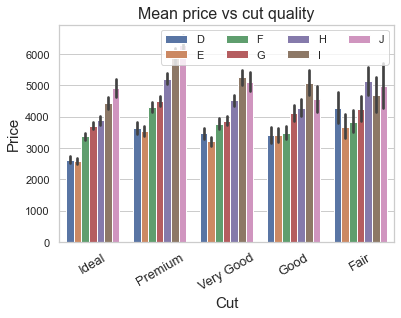

In [42]:
# Modifying the font-size and rotation of x-axis and adding title for the plot
ax = sns.barplot(x='cut', y='price', hue='color', data=diamonds_df)
ax.legend(loc='upper right', ncol=4)
ax.set_xlabel('Cut', fontdict={'fontsize':15})
ax.set_ylabel('Price', fontdict={'fontsize':15})

# Set fontsize and rotation of x-axis tick labels
ax.set_xticklabels(ax.get_xticklabels(), fontsize=13, rotation=30)

# Add a title for the plot
ax.set_title("Mean price vs cut quality", fontsize=16)